ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [6]:
# Load Dataset

df = pd.read_csv(
    '/content/online_retail.csv',
    encoding='latin1')

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Check Missing Values

In [7]:
# Check all values
print(df.isna())

        InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  \
0           False      False        False     False        False      False   
1           False      False        False     False        False      False   
2           False      False        False     False        False      False   
3           False      False        False     False        False      False   
4           False      False        False     False        False      False   
...           ...        ...          ...       ...          ...        ...   
541904      False      False        False     False        False      False   
541905      False      False        False     False        False      False   
541906      False      False        False     False        False      False   
541907      False      False        False     False        False      False   
541908      False      False        False     False        False      False   

        CustomerID  Country  
0            False   

In [8]:
print(df.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### Check duplicate rows

In [9]:
# checking duplicate rows
df.duplicated().sum()

np.int64(5268)

In [10]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


### No. of rows and columns

In [11]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (541909, 8) 

number of rows:  541909
number of columns:  8


### Data type of columns

In [12]:
# viewing the data types of columns
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [14]:
# Statistical summary

df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [17]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [16]:
# BEFORE CLEANING
df.shape

(541909, 8)

The dataset contains retail transaction records with columns such as InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country. The dataset was inspected using df.info(), df.shape, and df.describe() to understand its structure, data types, and summary statistics.

## Data Cleaning

In [18]:
# reset index (clean look)

df = df.reset_index(drop=True)

In [31]:
# removing duplicates and missing values to make the dataset clean
# correcting invalid values (negatives for example).

# Handle missing values
df = df.dropna(subset=['CustomerID', 'Description'])

# Remove duplicates
df = df.drop_duplicates()

# Convert data types
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Remove invalid values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Reset index
df = df.reset_index(drop=True)

In [41]:
# After Cleaning (to prove no dupliaces, missing values, invald values are left)
# now we have a better dataset that contains valid values.

df.isna().sum()


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [42]:
df.duplicated().sum()


np.int64(0)

In [43]:
print("Negative Quantity values:", (df['Quantity'] <= 0).sum())
print("Negative UnitPrice values:", (df['UnitPrice'] <= 0).sum())

Negative Quantity values: 0
Negative UnitPrice values: 0


## After Cleaning

In [45]:
df.head(-1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
392686,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680,France
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France


In [46]:
#AFTER CLEANING (reduced rows in df.shape show that cleanig of duplicates, missing values, incorret values were successful )

df.shape

(392692, 8)

The dataset contained missing values in the "Description" and "CustomerID" columns, which were removed to improve data quality. Additionally, duplicate rows were identified and removed. The dataset also contained incorrect and unrealistic values, such as negative quantities and unit prices, which were filtered out since they are not valid in a retail context. After cleaning, the dataset became more consistent, accurate, and suitable for analysis.

The number of rows decreased from 541,909 to 392,692 after cleaning, showing and proving that invalid and duplicate records were successfully removed.

### Before Cleaning (Messy Data) Screenshots

The dataset contains several issues, including missing values, duplicate records, and invalid values such as negative quantities and zero unit prices.




Duplicated data before cleaning

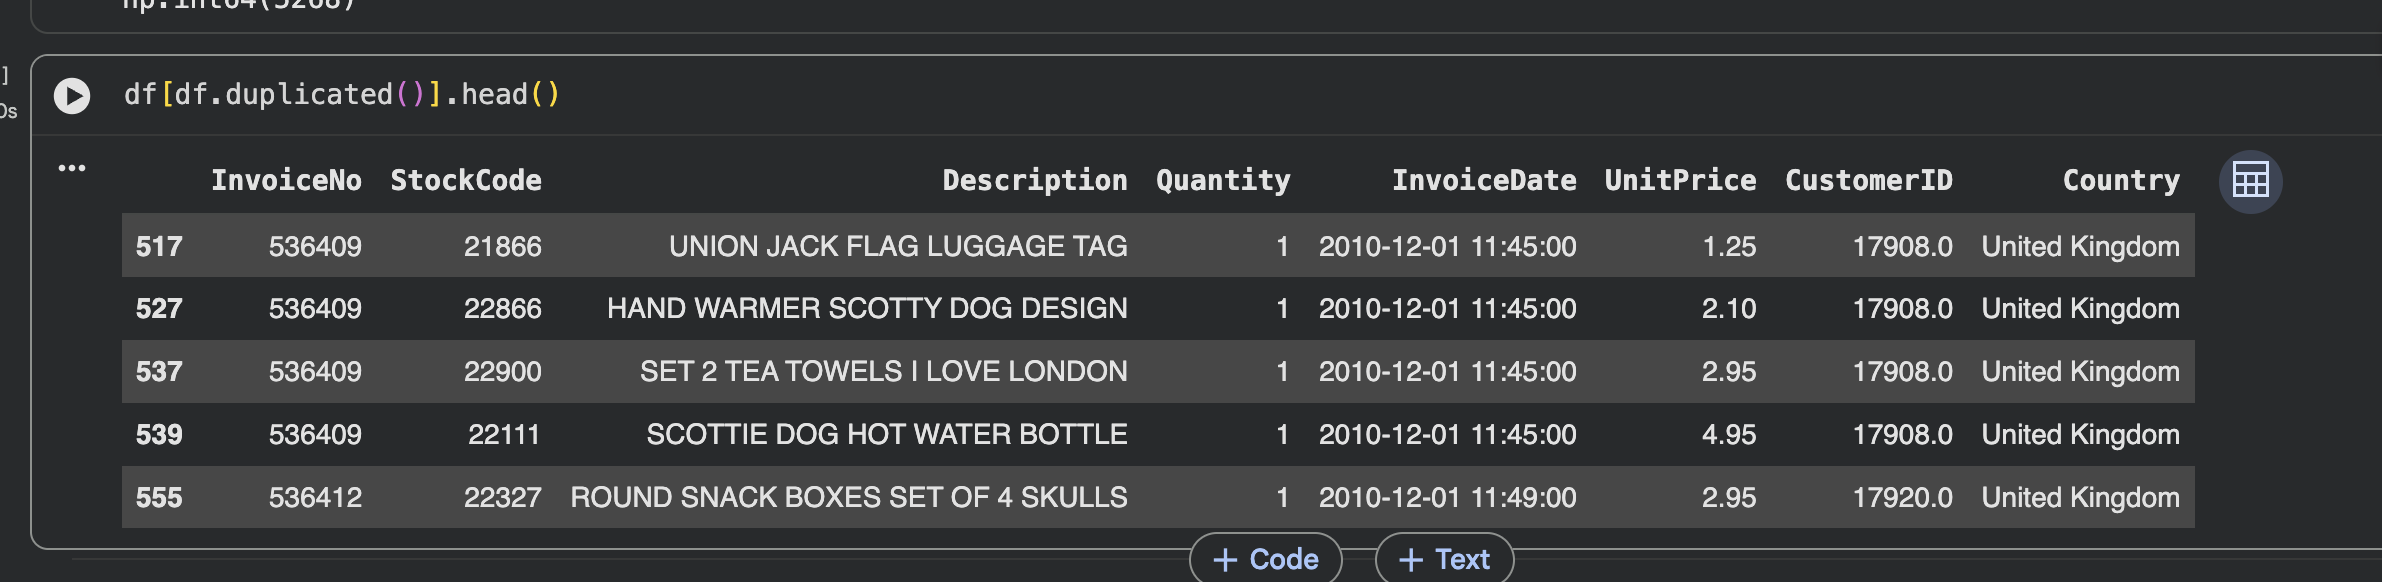

Missing Values before cleaning






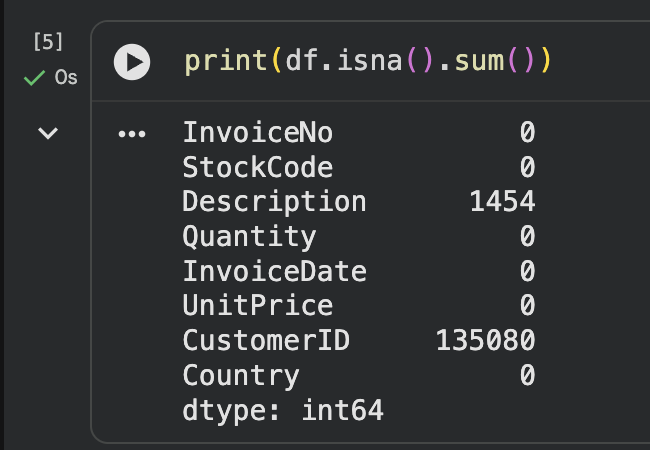



# After Cleaning Screenshots

no duplicate and missing values

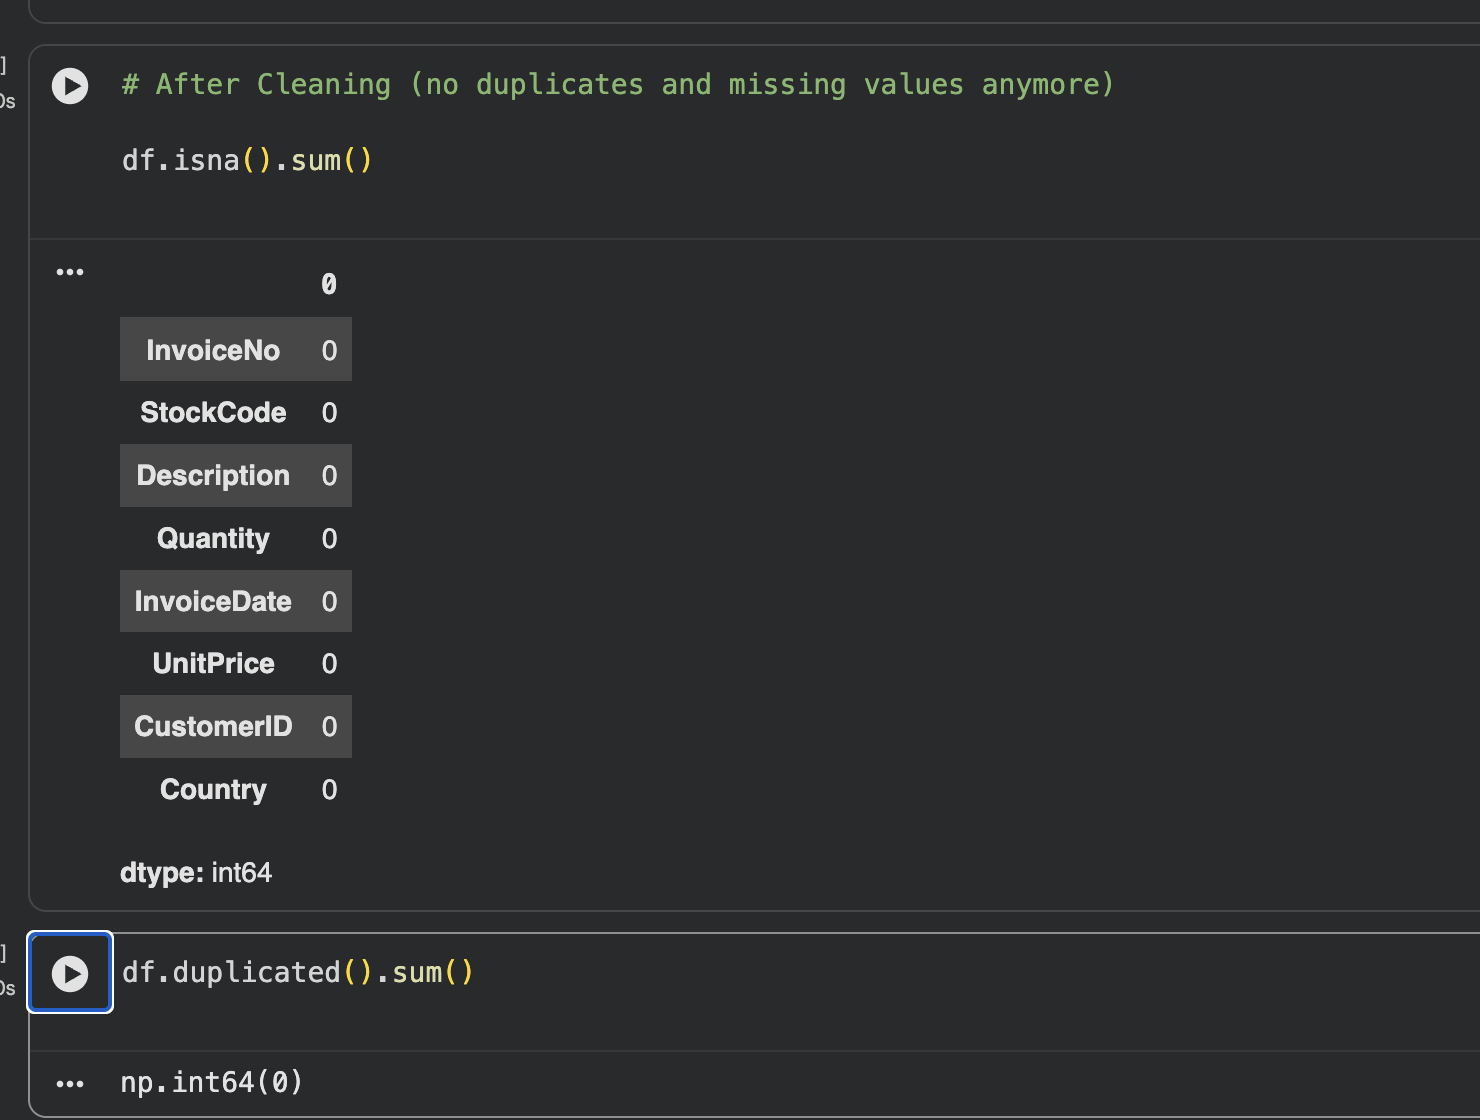

Negative values are removed

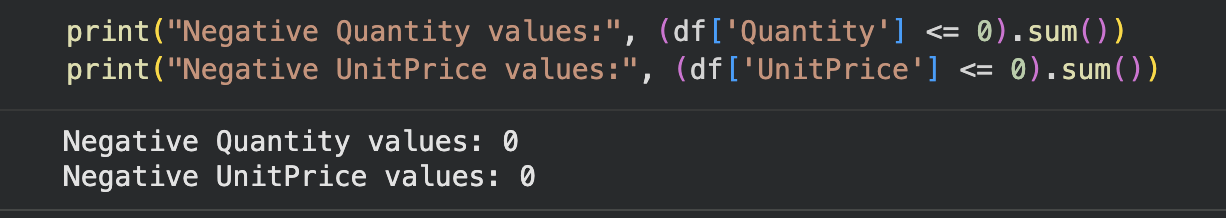

### Data Cleaning Steps

1. Removed missing values from "CustomerID" and "Description" columns using df.dropna(subset=['CustomerID', 'Description'])

2. Removed duplicate rows using df.drop_duplicates().
3. Filtered out invalid values such as:
   - Negative values in (Quantity) column
   - Unit prices that equal to zero
4. Lastly, I converted "InvoiceDate" to datetime format for better analysis.

## Data Visualization and Insights



## plot 1 - Top Countries

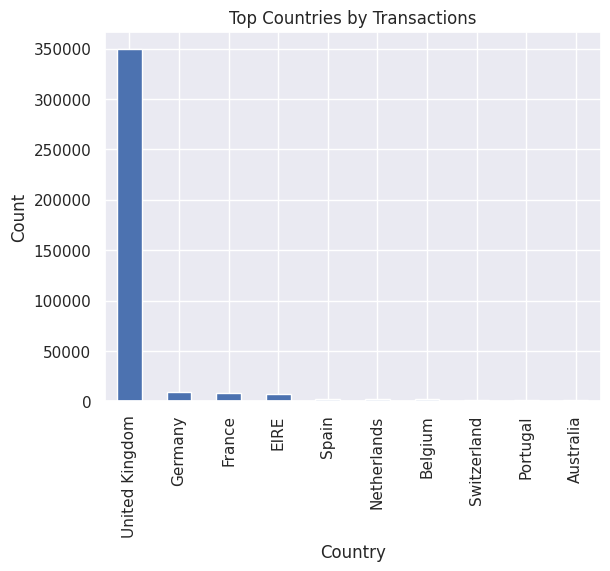

In [47]:
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top Countries by Transactions')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()


This bar chart shows the top countries based on number of transactions. It was chosen to identify which countries contribute most to the dataset. The chart shows that the United Kingdom has the highest number of transactions.

### Plot 2 - Quantity Distribution italicized text

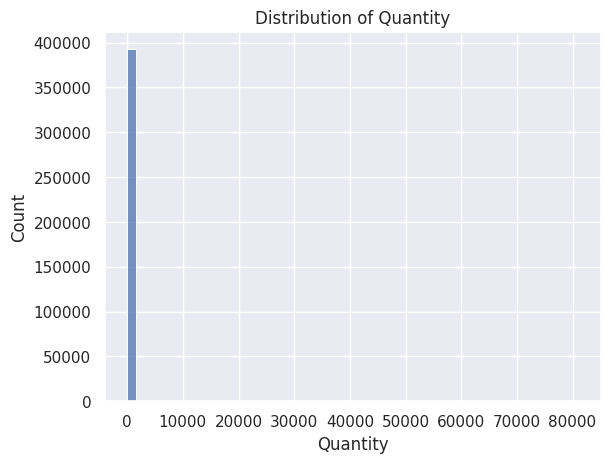

In [48]:
sns.histplot(df['Quantity'], bins=50)
plt.title('Distribution of Quantity')
plt.show()

This histogram shows the distribution of quantities before removing extreme values. Outliers causes the distribution to appear highly skewed and difficult to interpret.


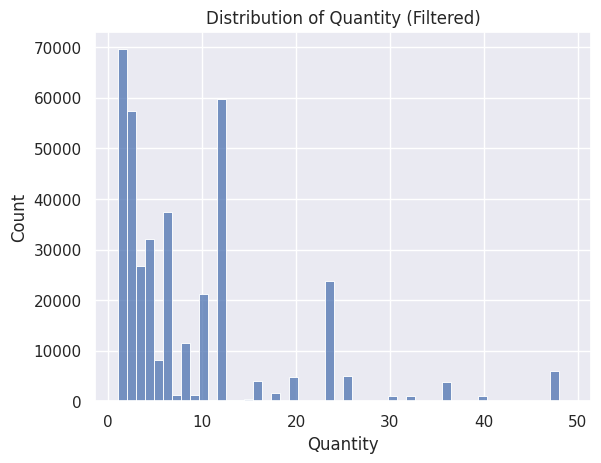

In [52]:
sns.histplot(df_filtered['Quantity'], bins=50)
plt.title('Distribution of Quantity (Filtered)')
plt.show()

After removing extreme values, the distribution became more clear. Most transactions involve small quantities, while large purchases are rare. We learn that Customers typically buy items in small amounts.

## plot 3 - Unit Price Distribution

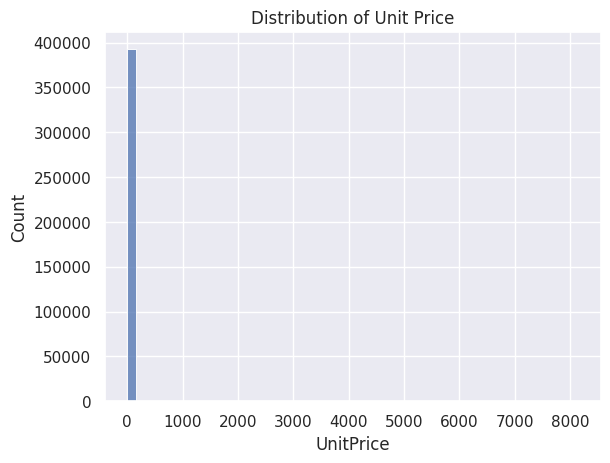

In [53]:
sns.histplot(df['UnitPrice'], bins=50)
plt.title('Distribution of Unit Price')
plt.show()

This histogram shows the distribution of unit prices before removing extreme values. Having very high prices causes the data to be highly skewed and difficult to interpret.

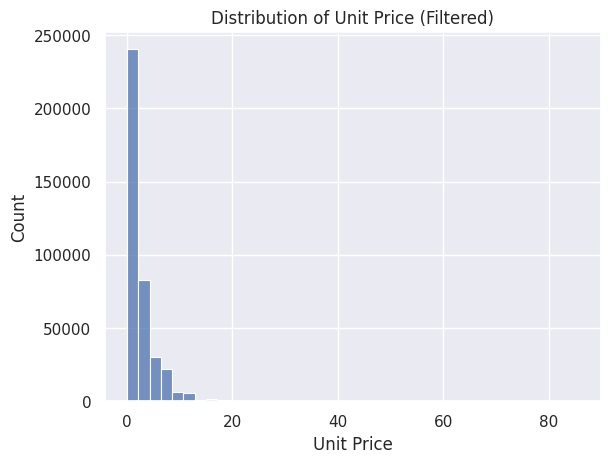

In [54]:
df_price = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] < 100)]

sns.histplot(df_price['UnitPrice'], bins=40)
plt.title('Distribution of Unit Price (Filtered)')
plt.xlabel('Unit Price')
plt.ylabel('Count')
plt.show()

After filtering unrealistic values, the distribution becomes clearer. Most products have low prices, while higher prices are less common which makes us learn that the business mainly deals with low-cost items.

### Plot 4 - Quantity vs price

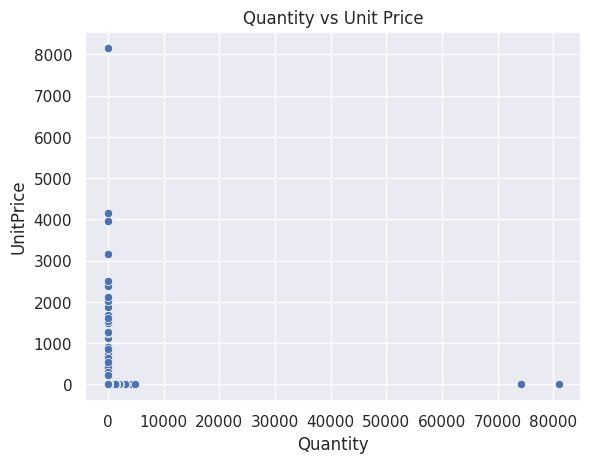

In [55]:
sns.scatterplot(x='Quantity', y='UnitPrice', data=df)
plt.title('Quantity vs Unit Price')
plt.show()

This scatter plot shows the relationship between quantity and unit price before removing outliers. The presence of extreme values makes it difficult to observe any clear pattern.

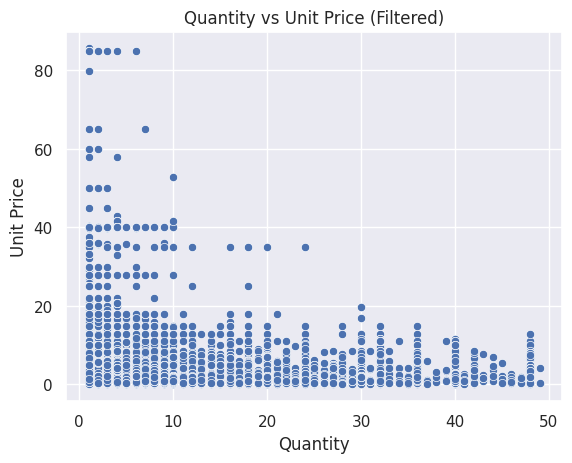

In [56]:
df_clean = df[
    (df['Quantity'] > 0) & (df['Quantity'] < 50) &
    (df['UnitPrice'] > 0) & (df['UnitPrice'] < 100)
]

sns.scatterplot(x='Quantity', y='UnitPrice', data=df_clean)
plt.title('Quantity vs Unit Price (Filtered)')
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.show()

After removing extreme values, the relationship becomes clearer. There is no strong correlation between quantity and unit price, indicating that price does not depend heavily on the quantity purchased.

### plot 5 - Top Products

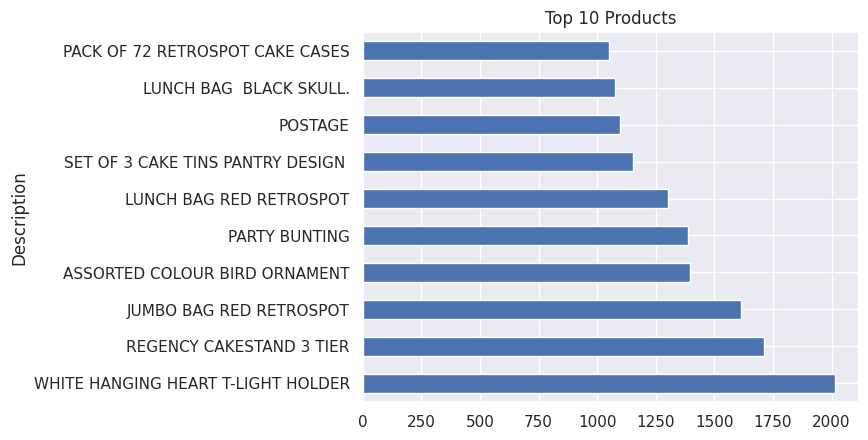

In [57]:
df['Description'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Products')
plt.show()

This chart shows the most frequently purchased products. It helps identify popular items. Some products appear significantly more often than others, indicating high demand.

### Plot 6 - Monthly Trend

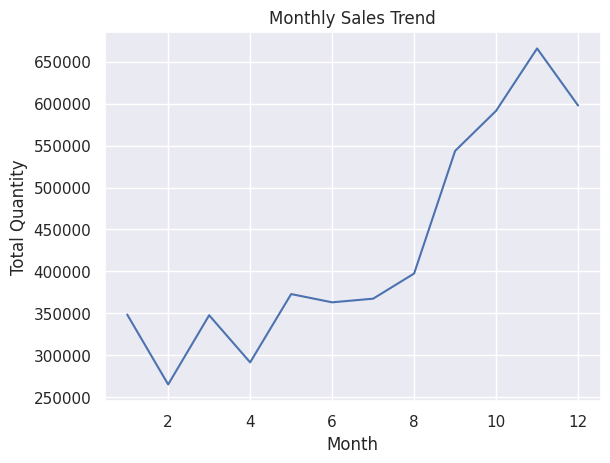

In [58]:
df['Month'] = df['InvoiceDate'].dt.month

df.groupby('Month')['Quantity'].sum().plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Quantity')
plt.show()

This line chart shows sales trends over months. It was chosen to identify seasonal patterns. The data indicates variations in sales across different months.

### plot 7 - boxplot (outliers)

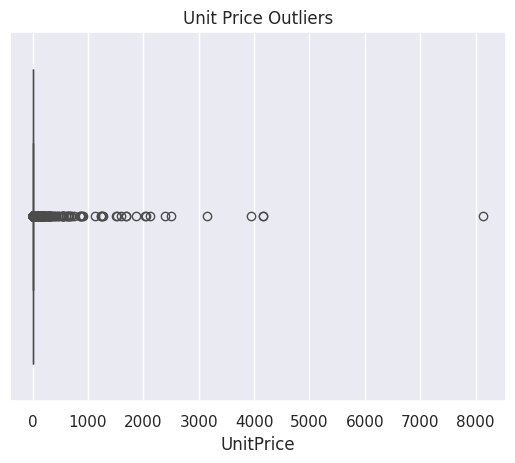

In [59]:
sns.boxplot(x=df['UnitPrice'])
plt.title('Unit Price Outliers')
plt.show()

This boxplot identifies outliers in unit prices. It shows that while most prices are low, there are some extreme values that are significantly higher.



### plot 8 - Correlation


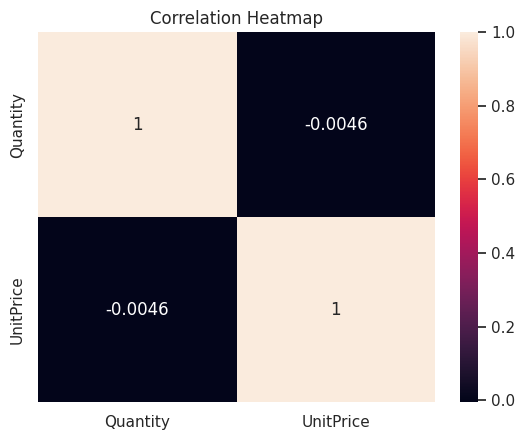

In [60]:
sns.heatmap(df[['Quantity','UnitPrice']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

This heatmap shows the correlation between numerical variables. It helps identify relationships between features. The correlation between quantity and unit price appears to be weak.

## Analysis Types

Univariate Analysis:
- Quantity distribution
- Unit price distribution
- Country frequency
- Top products

Bivariate Analysis:
- Quantity vs UnitPrice
- Correlation analysis

# Final Insights

Plotting differnt columns helped in analyzing and understanding the dataset better. It shows that most transactions come from the United Kingdom. The data also shows that most purchases involve smaller quantities and lower-priced items, with only a few cases of high values. In addition, some products appear much more frequently than others, showing that certain items are more popular. There are also a few extreme values in unit prices, but they are not common. Overall, the dataset reveals important patterns in customer purchasing behavior and product demand.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
